In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [3]:
df = pd.read_csv("preprocessed_earthquake_data.csv")

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
                             place   mag magType        type  \
0         113 km W of Petrolia, CA  2.56      md  earthquake   
1               9 km N of Taft, CA  1.54      ml  earthquake   
2        58 km WNW of Petrolia, CA  2.84      md  earthquake   
3  24 km NNW of Searles Valley, CA  1.49      ml  earthquake   
4            12 km WNW of Anza, CA  0.56      ml  earthquake   

                      time   longitude   latitude  depth_km  sig net   nst  \
0  2025-02-11 14:34:38.190 -125.614334  40.216499      4.95  101  nc  14.0   
1  2025-02-11 14:28:19.490 -119.456833  35.225167     18.24   36  ci  31.0   
2  2025-02-11 14:24:27.270 -124.964500  40.401165      4.20  124  nc  30.0   
3  2025-02-11 14:24:22.730 -117.515663  35.967335      4.01   34  ci  19.0   
4  2025-02-11 14:12:30.720 -116.803167  33.584500      8.69    5  ci  25.0   

      dmin   rms    gap    year  month   day magnitude_level  
0  0.97600  0.12  325.0  2025.0    2.0  11.0           

In [4]:
print("Missing Values Before:")
print(df.isnull().sum())

# Fill numeric NaN
df = df.fillna(df.mean(numeric_only=True))

print("\nMissing Values After:")
print(df.isnull().sum())

Missing Values Before:
place                0
mag                  0
magType              0
type                 0
time                71
longitude            0
latitude             0
depth_km             0
sig                  0
net                  0
nst                  0
dmin                 0
rms                  0
gap                  0
year                71
month               71
day                 71
magnitude_level    958
dtype: int64

Missing Values After:
place                0
mag                  0
magType              0
type                 0
time                71
longitude            0
latitude             0
depth_km             0
sig                  0
net                  0
nst                  0
dmin                 0
rms                  0
gap                  0
year                 0
month                0
day                  0
magnitude_level    958
dtype: int64


In [5]:
df['magnitude_category'] = pd.cut(
    df['mag'],
    bins=[0, 2.5, 5, 10],
    labels=['Low', 'Medium', 'High']
)

# Remove NaN target rows
df = df.dropna(subset=['magnitude_category'])

# Check class distribution
print("\nClass Distribution:")
print(df['magnitude_category'].value_counts())


Class Distribution:
magnitude_category
Low       6165
Medium     462
High         0
Name: count, dtype: int64


In [6]:
X = df[['latitude', 'longitude', 'depth_km', 'sig']]
y = df['magnitude_category']

# Final check (VERY IMPORTANT)
print("\nCheck NaN in X:\n", X.isnull().sum())
print("\nCheck NaN in y:\n", y.isnull().sum())


Check NaN in X:
 latitude     0
longitude    0
depth_km     0
sig          0
dtype: int64

Check NaN in y:
 0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5301, 4)
Testing Data: (1326, 4)


In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully")

✅ Random Forest Model Trained Successfully


In [9]:
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9962292609351433

Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00      1238
      Medium       0.95      1.00      0.97        88

    accuracy                           1.00      1326
   macro avg       0.97      1.00      0.99      1326
weighted avg       1.00      1.00      1.00      1326



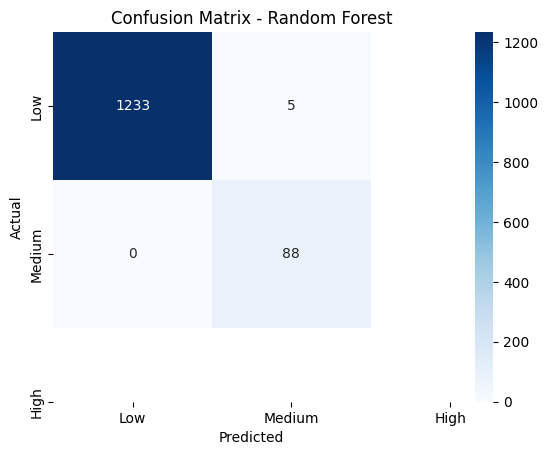

In [10]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [11]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

print("✅ Gradient Boosting Model Trained Successfully")

✅ Gradient Boosting Model Trained Successfully


In [12]:
y_pred_gb = gb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Accuracy: 0.9962292609351433

Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00      1238
      Medium       0.95      1.00      0.97        88

    accuracy                           1.00      1326
   macro avg       0.97      1.00      0.99      1326
weighted avg       1.00      1.00      1.00      1326



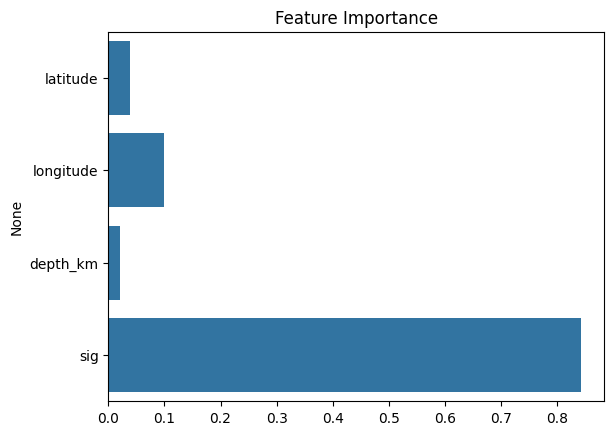

In [13]:
importances = rf_model.feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

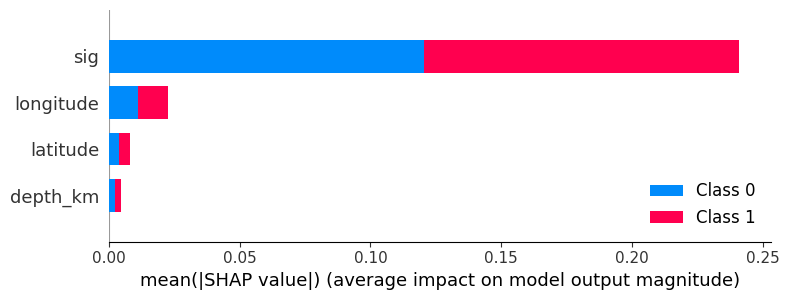

In [14]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [15]:
sample = pd.DataFrame(
    [[7.02, 10.0, 9.0, 8.0]],
    columns=['latitude', 'longitude', 'depth_km', 'sig']
)

prediction = rf_model.predict(sample)

print("Predicted Magnitude Category:", prediction[0])

Predicted Magnitude Category: Low
